## Changing Approach to Duplicates
Post-Project.

Using the Points of Interest that show up multiple times to get more information on the number of Bike Spots around Points of Interest.


In [1]:
# imports
import pandas as pd
import matplotlib.pyplot as plt

# Foursquare Data

In [2]:
# importing the data
FSCRData = pd.read_csv('../data/FoursquareData.csv')
FSCRData

,Name,Category ID,Category Name,Latitude,Longitude,Distance,Popularity,Price,Rating,Description
0,Ravintola Paulette,13148,French Restaurant,60.158526,24.945557,435,0.981589,2.0,9.1,NaN
1,Kaffa Roastery,13034,Café,60.158463,24.934133,939,0.992039,2.0,9.0,NaN
2,Daddy Greens Pizzabar - Iso Roobertinkatu,13064,Pizzeria,60.162840,24.940647,984,0.981128,1.0,8.8,Daddy Greens Pizzabar is a pizzeria in Töölö a...
3,Ravintola Skiffer,13064,Pizzeria,60.152901,24.946306,354,0.967701,2.0,8.7,NaN
4,Ravintola Pastis,13148,French Restaurant,60.164127,24.947772,979,0.982049,2.0,8.6,Autenttinen maalaisranskalainen keittiö ja tun...
...,...,...,...,...,...,...,...,...,...,...
25024,Ravintola Töölö,13022,Sports Bar,60.188297,24.917887,580,0.985921,1.0,4.9,NaN
25025,Hesburger Helsinki Töölö,13145,Fast Food Restaurant,60.184169,24.924048,99,0.979148,1.0,4.9,The factors behind Hesburger’s success are tas...
25026,Neste K Eläintarha,13034,Café,60.193018,24.930322,961,0.996032,NaN,4.8,Neste K Helsinki Eläintarha on 24h palveleva l...
25027,HSL 1915 Töölön Kisahalli,19043,Bus Stop,60.184650,24.923348,119,0.989687,NaN,NaN,NaN


In [3]:
# removing values that are a further distance than the expected radius of 1000m
FSCRDataWithinRadius = pd.DataFrame(FSCRData[FSCRData['Distance'] <= 1000])
FSCRDataWithinRadius

,Name,Category ID,Category Name,Latitude,Longitude,Distance,Popularity,Price,Rating,Description
0,Ravintola Paulette,13148,French Restaurant,60.158526,24.945557,435,0.981589,2.0,9.1,NaN
1,Kaffa Roastery,13034,Café,60.158463,24.934133,939,0.992039,2.0,9.0,NaN
2,Daddy Greens Pizzabar - Iso Roobertinkatu,13064,Pizzeria,60.162840,24.940647,984,0.981128,1.0,8.8,Daddy Greens Pizzabar is a pizzeria in Töölö a...
3,Ravintola Skiffer,13064,Pizzeria,60.152901,24.946306,354,0.967701,2.0,8.7,NaN
4,Ravintola Pastis,13148,French Restaurant,60.164127,24.947772,979,0.982049,2.0,8.6,Autenttinen maalaisranskalainen keittiö ja tun...
...,...,...,...,...,...,...,...,...,...,...
25024,Ravintola Töölö,13022,Sports Bar,60.188297,24.917887,580,0.985921,1.0,4.9,NaN
25025,Hesburger Helsinki Töölö,13145,Fast Food Restaurant,60.184169,24.924048,99,0.979148,1.0,4.9,The factors behind Hesburger’s success are tas...
25026,Neste K Eläintarha,13034,Café,60.193018,24.930322,961,0.996032,NaN,4.8,Neste K Helsinki Eläintarha on 24h palveleva l...
25027,HSL 1915 Töölön Kisahalli,19043,Bus Stop,60.184650,24.923348,119,0.989687,NaN,NaN,NaN


In [4]:
# getting the count of unique distances per Point of Interest. the distance is from a Bike Spot; unique values are unique Bike Spots
FSCRDataGroupedPOI = FSCRDataWithinRadius.groupby(['Name','Latitude','Longitude'])['Distance'].nunique()
FSCRDataGroupedPOI

Name                                Latitude   Longitude
10 Hammas                           60.210997  25.079795     1
3Amigos                             60.293003  25.036842     1
60° Bar & Brewery                   60.316169  24.971572     1
88-Burgers                          60.228628  24.962211     6
99 Burgers                          60.228553  24.961850     9
                                                            ..
ms Koningsdam Culinary Arts Center  60.155296  24.922520     4
Ääniwalli                           60.195243  24.949869    21
Ölhus Helsinki                      60.189454  24.916251    12
Наша Дорога                         60.145671  24.909756     1
المطعم اليمني Yemeni Restaurant     60.192735  25.042747     5
Name: Distance, Length: 4610, dtype: int64

In [5]:
# resetting index to convert the groupby object into a DataFrame
FSCRDataGroupedPOI = FSCRDataGroupedPOI.reset_index(name='Bike Spots Near')
FSCRDataGroupedPOI

,Name,Latitude,Longitude,Bike Spots Near
0,10 Hammas,60.210997,25.079795,1
1,3Amigos,60.293003,25.036842,1
2,60° Bar & Brewery,60.316169,24.971572,1
3,88-Burgers,60.228628,24.962211,6
4,99 Burgers,60.228553,24.961850,9
...,...,...,...,...
4605,ms Koningsdam Culinary Arts Center,60.155296,24.922520,4
4606,Ääniwalli,60.195243,24.949869,21
4607,Ölhus Helsinki,60.189454,24.916251,12
4608,Наша Дорога,60.145671,24.909756,1


In [6]:
# counting occurences of locations
FSCRDataFrequency = FSCRDataGroupedPOI['Bike Spots Near'].value_counts().sort_index()
FSCRDataFrequency

Bike Spots Near
1     641
2     654
3     628
4     557
5     449
6     345
7     301
8     262
9     193
10    101
11     91
12     78
13     61
14     31
15     39
16     22
17     27
18     23
19     16
20     15
21     13
22     11
23      4
24     10
25      4
26      4
27      4
28      5
29      3
30      4
31      3
32      3
33      6
34      2
Name: count, dtype: int64

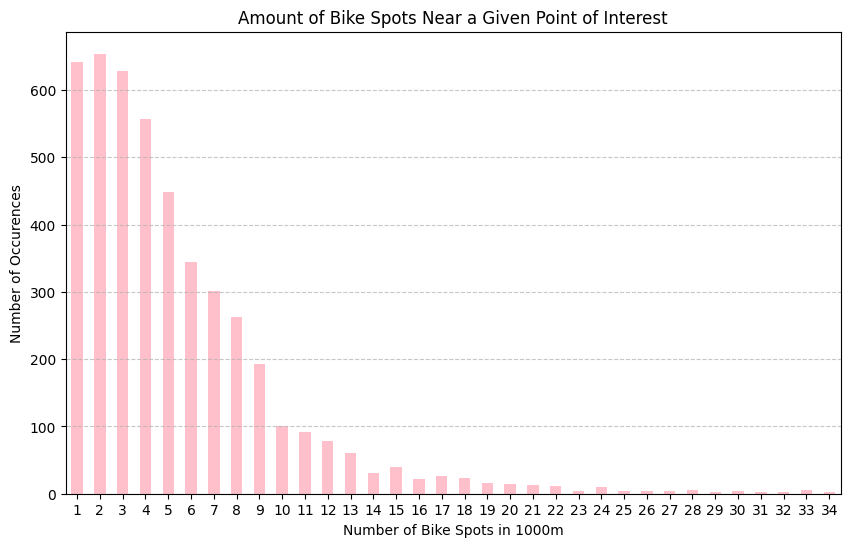

In [7]:
# plotting the frequency of Bike Spots near Points of Interest
plt.figure(figsize=(10, 6))
FSCRDataFrequency.plot(kind='bar', color='pink')
plt.title('Amount of Bike Spots Near a Given Point of Interest')
plt.xlabel('Number of Bike Spots in 1000m')
plt.ylabel('Number of Occurences')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

We can see that most of the Points of Interest are near less than 10 Bike Spots.

In [8]:
# checking if duplicate POIs have different values
FSCRDataWithinRadius.duplicated(subset=['Name','Latitude','Longitude']).value_counts() == FSCRDataWithinRadius.duplicated(subset=['Name','Latitude','Longitude','Popularity']).value_counts()

True     False
False    False
Name: count, dtype: bool

In [9]:
# identifying POI with duplicates
FSPOIDuplicates = FSCRDataWithinRadius[FSCRDataWithinRadius.duplicated(subset=['Name','Latitude','Longitude'], keep=False)]
FSPOIDuplicates

,Name,Category ID,Category Name,Latitude,Longitude,Distance,Popularity,Price,Rating,Description
0,Ravintola Paulette,13148,French Restaurant,60.158526,24.945557,435,0.981589,2.0,9.1,NaN
1,Kaffa Roastery,13034,Café,60.158463,24.934133,939,0.992039,2.0,9.0,NaN
3,Ravintola Skiffer,13064,Pizzeria,60.152901,24.946306,354,0.967701,2.0,8.7,NaN
4,Ravintola Pastis,13148,French Restaurant,60.164127,24.947772,979,0.982049,2.0,8.6,Autenttinen maalaisranskalainen keittiö ja tun...
5,Restaurant Elm,13065,Restaurant,60.156974,24.952636,217,0.989517,NaN,8.6,NaN
...,...,...,...,...,...,...,...,...,...,...
25024,Ravintola Töölö,13022,Sports Bar,60.188297,24.917887,580,0.985921,1.0,4.9,NaN
25025,Hesburger Helsinki Töölö,13145,Fast Food Restaurant,60.184169,24.924048,99,0.979148,1.0,4.9,The factors behind Hesburger’s success are tas...
25026,Neste K Eläintarha,13034,Café,60.193018,24.930322,961,0.996032,NaN,4.8,Neste K Helsinki Eläintarha on 24h palveleva l...
25027,HSL 1915 Töölön Kisahalli,19043,Bus Stop,60.184650,24.923348,119,0.989687,NaN,NaN,NaN


In [10]:
# identifying the differing Popularity values for duplicated POIs
FSPopularityDuplicates = FSPOIDuplicates.groupby(['Name','Latitude','Longitude'])['Popularity'].nunique()

# any count greater than 1 indicates a POI with a different Popularity value
FSUniquePopularityValues = FSPopularityDuplicates[FSPopularityDuplicates > 1]

# identifying these rows
FSPopularityDifference = FSPOIDuplicates[FSPOIDuplicates.set_index(['Name','Latitude','Longitude']).index.isin(FSUniquePopularityValues.index)]
FSPopularityDifference

,Name,Category ID,Category Name,Latitude,Longitude,Distance,Popularity,Price,Rating,Description
4733,Espoon kaupunki Sellon kirjasto,12080,Library,60.217506,24.809773,773,0.998876,NaN,8.0,Sellon kirjasto on osa Espoon kaupunginkirjast...
4776,Espoon kaupunki Sellon kirjasto,12080,Library,60.217506,24.809773,773,0.066917,NaN,NaN,NaN
4783,Espoon kaupunki Sellon kirjasto,12080,Library,60.217506,24.809773,987,0.998876,NaN,8.0,Sellon kirjasto on osa Espoon kaupunginkirjast...
4834,Espoon kaupunki Sellon kirjasto,12080,Library,60.217506,24.809773,553,0.998876,NaN,8.0,Sellon kirjasto on osa Espoon kaupunginkirjast...
4865,Espoon kaupunki Sellon kirjasto,12080,Library,60.217506,24.809773,553,0.066917,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
23954,HSL V5104 Veromäen koulu,19043,Bus Stop,60.286619,24.960057,816,0.935900,NaN,NaN,NaN
24017,HSL V5104 Veromäen koulu,19043,Bus Stop,60.286619,24.960057,580,0.698479,NaN,NaN,NaN
24018,HSL V5104 Veromäen koulu,19043,Bus Stop,60.286619,24.960057,580,0.935900,NaN,NaN,NaN
24701,HSL V5104 Veromäen koulu,19043,Bus Stop,60.286619,24.960057,998,0.698479,NaN,NaN,NaN


In [11]:
# some POIs are duplicated from being returned relative to the same Bike Spot. if they have the same distance, it's from the same Bike Spot.
# this means a slightly different approach will be needed to get the amount of Bike Spots near a given Point of Interest

In [12]:
# seeing how many non-null values there are for Price and Rating
FSCRDataWithinRadius.count()

Name             25019
Category ID      25019
Category Name    25019
Latitude         25019
Longitude        25019
Distance         25019
Popularity       24112
Price            10207
Rating            7889
Description       6325
dtype: int64

In [13]:
# a way to handle null values for Price and Rating would be to treat these columns as categorical ones instead of numerical ones and make a category for these null values

In [14]:
# identifying the differing Price values for duplicated POIs
FSPriceDuplicates = FSPOIDuplicates.groupby(['Name','Latitude','Longitude'])['Price'].nunique()

# any count greater than 1 indicates a POI with a different Popularity value
FSUniquePriceValues = FSPriceDuplicates[FSPriceDuplicates > 1]

# identifying these rows
FSPriceDifference = FSPOIDuplicates[FSPOIDuplicates.set_index(['Name','Latitude','Longitude']).index.isin(FSUniquePriceValues.index)]
FSPriceDifference

# no difference in Price for same POI

,Name,Category ID,Category Name,Latitude,Longitude,Distance,Popularity,Price,Rating,Description


In [15]:
# getting all Price values
FSCRDataWithinRadius.Price.value_counts().sort_index()

Price
1.0    4736
2.0    4471
3.0     950
4.0      50
Name: count, dtype: int64

In [16]:
# identifying the differing Rating values for duplicated POIs
FSRatingDuplicates = FSPOIDuplicates.groupby(['Name','Latitude','Longitude'])['Rating'].nunique()

# any count greater than 1 indicates a POI with a different Popularity value
FSUniqueRatingValues = FSRatingDuplicates[FSRatingDuplicates > 1]

# identifying these rows
FSRatingDifference = FSPOIDuplicates[FSPOIDuplicates.set_index(['Name','Latitude','Longitude']).index.isin(FSUniqueRatingValues.index)]
FSRatingDifference

# no difference in Rating for same POI

,Name,Category ID,Category Name,Latitude,Longitude,Distance,Popularity,Price,Rating,Description


In [17]:
# getting all Rating values
FSCRDataWithinRadius.Rating.value_counts().sort_index()

Rating
4.5     10
4.6      5
4.7     47
4.8    104
4.9    110
5.0     83
5.1    101
5.2    136
5.3    150
5.4    177
5.5    104
5.6    127
5.7    145
5.8    167
5.9    157
6.0    125
6.1    216
6.2    148
6.3    217
6.4    205
6.5    157
6.6     98
6.7    234
6.8    124
6.9    127
7.0    223
7.1    134
7.2    258
7.3    236
7.4    245
7.5    179
7.6    306
7.7    277
7.8    332
7.9    194
8.0    269
8.1    183
8.2    183
8.3    134
8.4    302
8.5    103
8.6    275
8.7    273
8.8    118
8.9     86
9.0    110
9.1     37
9.2     44
9.3     88
9.4     26
Name: count, dtype: int64

In [18]:
# for Ratings, they go from 4.5 to 9.1
# it might be worthwhile to group ratings into ranges (4, 5, 6, 7, 8, 9, and Not Rated)
# we can treat Rating as categorical 

In [19]:
# getting mean min max for Popularity
FSCRDataPopularities = FSCRDataWithinRadius.groupby(['Name','Latitude','Longitude']).agg({'Popularity': ['mean', 'min', 'max']})
FSCRDataPopularities

Popularity            \
                                                             mean       min   
Name                               Latitude  Longitude                        
10 Hammas                          60.210997 25.079795        NaN       NaN   
3Amigos                            60.293003 25.036842   0.970977  0.970977   
60° Bar & Brewery                  60.316169 24.971572   0.995157  0.995157   
88-Burgers                         60.228628 24.962211        NaN       NaN   
99 Burgers                         60.228553 24.961850   0.954020  0.954020   
...                                                           ...       ...   
ms Koningsdam Culinary Arts Center 60.155296 24.922520   0.049576  0.049576   
Ääniwalli                          60.195243 24.949869   0.983286  0.983286   
Ölhus Helsinki                     60.189454 24.916251   0.978146  0.978146   
Наша Дорога                        60.145671 24.909756   0.463919  0.463919   
المطعم اليمني Yemeni Restaurant    60.192735 25.042747   0.966176  0.966176   

                                                                  
                                                             max  
Name                               Latitude  Longitude            
10 Hammas                          60.210997 25.079795       NaN  
3Amigos                            60.293003 25.036842  0.970977  
60° Bar & Brewery                  60.316169 24.971572  0.995157  
88-Burgers                         60.228628 24.962211       NaN  
99 Burgers                         60.228553 24.961850  0.954020  
...                                                          ...  
ms Koningsdam Culinary Arts Center 60.155296 24.922520  0.049576  
Ääniwalli                          60.195243 24.949869  0.983286  
Ölhus Helsinki                     60.189454 24.916251  0.978146  
Наша Дорога                        60.145671 24.909756  0.463919  
المطعم اليمني Yemeni Restaurant    60.192735 25.042747  0.966176  

[4610 rows x 3 columns]

In [20]:
# preparing the data for visualization
# flattening the multi-index columns and resetting the index
FSCRDataPopularities.columns = ['_'.join(col).strip() for col in FSCRDataPopularities.columns.values]
FSCRDataPopularities = FSCRDataPopularities.reset_index()
FSCRDataPopularities

,Name,Latitude,Longitude,Popularity_mean,Popularity_min,Popularity_max
0,10 Hammas,60.210997,25.079795,NaN,NaN,NaN
1,3Amigos,60.293003,25.036842,0.970977,0.970977,0.970977
2,60° Bar & Brewery,60.316169,24.971572,0.995157,0.995157,0.995157
3,88-Burgers,60.228628,24.962211,NaN,NaN,NaN
4,99 Burgers,60.228553,24.961850,0.954020,0.954020,0.954020
...,...,...,...,...,...,...
4605,ms Koningsdam Culinary Arts Center,60.155296,24.922520,0.049576,0.049576,0.049576
4606,Ääniwalli,60.195243,24.949869,0.983286,0.983286,0.983286
4607,Ölhus Helsinki,60.189454,24.916251,0.978146,0.978146,0.978146
4608,Наша Дорога,60.145671,24.909756,0.463919,0.463919,0.463919


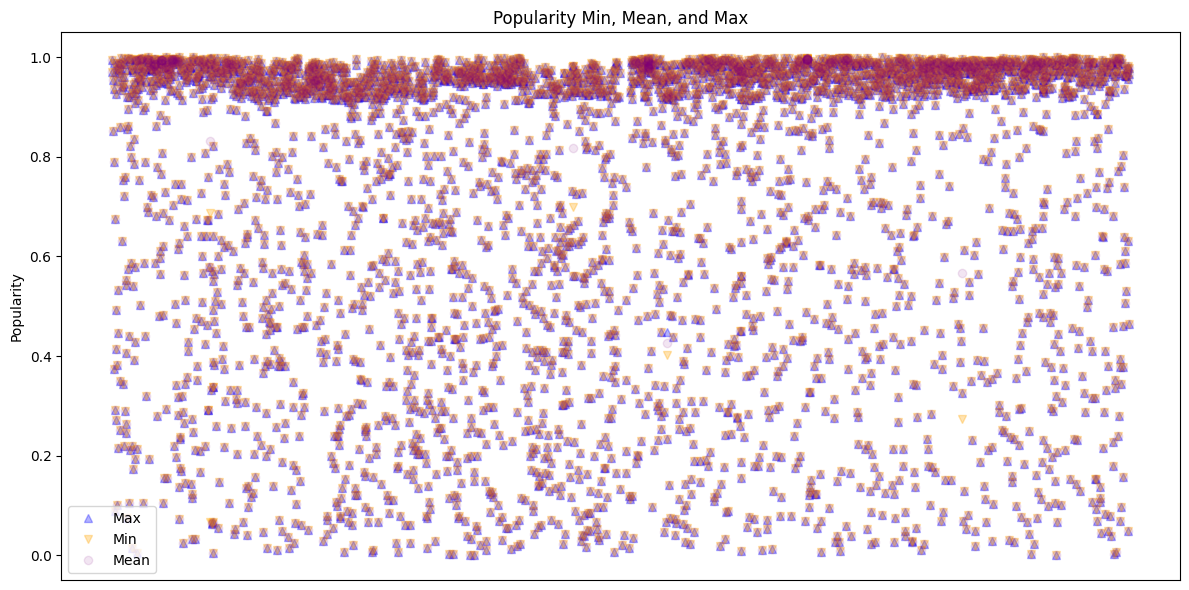

In [21]:
# visualizing the popularities
plt.figure(figsize=(12, 6))
# plot Point of Interest and Popularity values, no lines visible, transparent markers to see all of them
plt.plot(FSCRDataPopularities['Name'], FSCRDataPopularities['Popularity_max'], linewidth=0, alpha = 0.3, label='Max', marker='^', color='blue')
plt.plot(FSCRDataPopularities['Name'], FSCRDataPopularities['Popularity_min'], linewidth=0, alpha = 0.3, label='Min', marker='v', color='orange')
plt.plot(FSCRDataPopularities['Name'], FSCRDataPopularities['Popularity_mean'], linewidth=0, alpha = 0.1, label='Mean', marker='o', color='purple')
plt.ylabel('Popularity')
plt.title('Popularity Min, Mean, and Max')
plt.xticks([])
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
# most Points of Interest don't have varying popularity values

In [23]:
FSCRDataDistances = FSCRDataWithinRadius.groupby(['Name','Latitude','Longitude']).agg({'Distance': ['mean', 'min', 'max']})
FSCRDataDistances

Distance          
                                                              mean  min  max
Name                               Latitude  Longitude                      
10 Hammas                          60.210997 25.079795  997.000000  997  997
3Amigos                            60.293003 25.036842  964.000000  964  964
60° Bar & Brewery                  60.316169 24.971572  362.000000  362  362
88-Burgers                         60.228628 24.962211  776.666667  590  944
99 Burgers                         60.228553 24.961850  623.555556   98  966
...                                                            ...  ...  ...
ms Koningsdam Culinary Arts Center 60.155296 24.922520  688.500000  597  814
Ääniwalli                          60.195243 24.949869  687.714286  171  998
Ölhus Helsinki                     60.189454 24.916251  526.000000  207  856
Наша Дорога                        60.145671 24.909756  625.000000  625  625
المطعم اليمني Yemeni Restaurant    60.192735 25.042747  542.333333    9  792

[4610 rows x 3 columns]

In [24]:
# preparing the data for visualization
# flattening the multi-index columns and resetting the index
FSCRDataDistances.columns = ['_'.join(col).strip() for col in FSCRDataDistances.columns.values]
FSCRDataDistances = FSCRDataDistances.reset_index()
FSCRDataDistances

,Name,Latitude,Longitude,Distance_mean,Distance_min,Distance_max
0,10 Hammas,60.210997,25.079795,997.000000,997,997
1,3Amigos,60.293003,25.036842,964.000000,964,964
2,60° Bar & Brewery,60.316169,24.971572,362.000000,362,362
3,88-Burgers,60.228628,24.962211,776.666667,590,944
4,99 Burgers,60.228553,24.961850,623.555556,98,966
...,...,...,...,...,...,...
4605,ms Koningsdam Culinary Arts Center,60.155296,24.922520,688.500000,597,814
4606,Ääniwalli,60.195243,24.949869,687.714286,171,998
4607,Ölhus Helsinki,60.189454,24.916251,526.000000,207,856
4608,Наша Дорога,60.145671,24.909756,625.000000,625,625


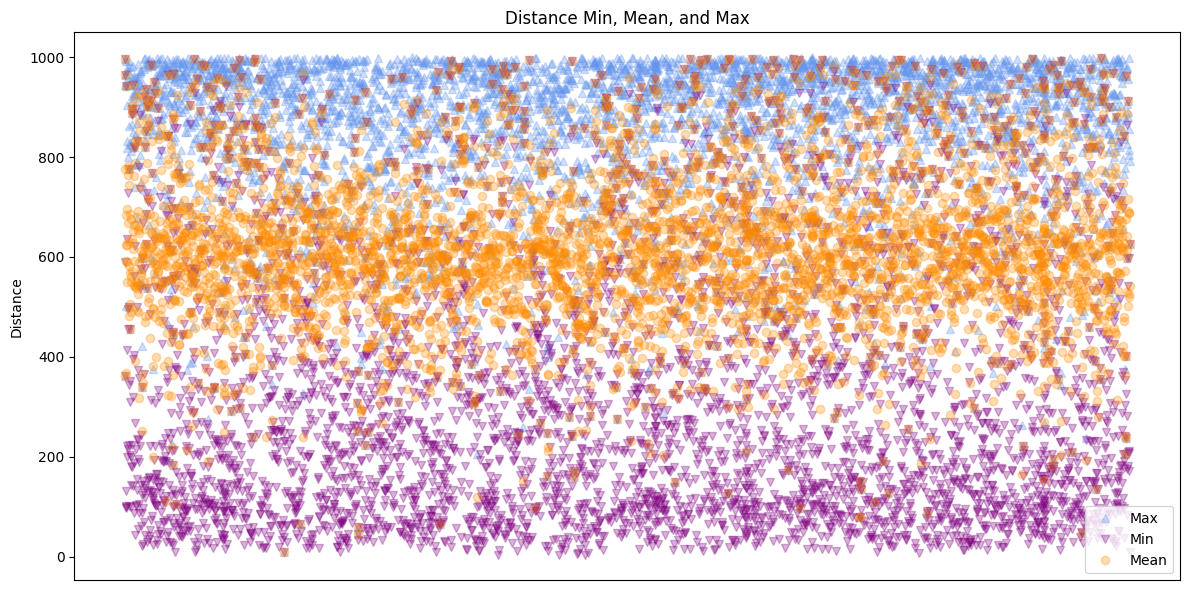

In [25]:
# visualizing the distances
plt.figure(figsize=(12, 6))
# plot Point of Interest and Distance values, no lines visible, transparent markers to see all of them
plt.plot(FSCRDataDistances['Name'], FSCRDataDistances['Distance_max'], linewidth=0, alpha = 0.3, label='Max', marker='^', color='cornflowerblue')
plt.plot(FSCRDataDistances['Name'], FSCRDataDistances['Distance_min'], linewidth=0, alpha = 0.3, label='Min', marker='v', color='purple')
plt.plot(FSCRDataDistances['Name'], FSCRDataDistances['Distance_mean'], linewidth=0, alpha = 0.3, label='Mean', marker='o', color='darkorange')
plt.ylabel('Distance')
plt.title('Distance Min, Mean, and Max')
plt.xticks([])
plt.legend()
plt.tight_layout()
plt.show()

Some locations are quite close to all the Bike Spots they are within a 1000m range of.

In [26]:
# changing data type so I can make Price values more descriptive of their meaning
FSCRDataWithinRadius = FSCRDataWithinRadius.astype({'Price':str})
FSCRDataWithinRadius['Price']

0        2.0
1        2.0
2        1.0
3        2.0
4        2.0
        ... 
25024    1.0
25025    1.0
25026    nan
25027    nan
25028    2.0
Name: Price, Length: 25019, dtype: object

In [27]:
# documentation states the range for price goes from most affordable (1) to most expensive (4). I am naming according to this. 
FSCRDataWithinRadius.loc[FSCRDataWithinRadius['Price'] == '1.0', 'Price'] = 'Most Affordable'
FSCRDataWithinRadius.loc[FSCRDataWithinRadius['Price'] == '2.0', 'Price'] = 'Affordable'
FSCRDataWithinRadius.loc[FSCRDataWithinRadius['Price'] == '3.0', 'Price'] = 'Expensive'
FSCRDataWithinRadius.loc[FSCRDataWithinRadius['Price'] == '4.0', 'Price'] = 'Most Expensive'

# adding additional category for nulls.
FSCRDataWithinRadius.loc[FSCRDataWithinRadius['Price'] == 'nan', 'Price'] = 'Not Listed'

FSCRDataWithinRadius

,Name,Category ID,Category Name,Latitude,Longitude,Distance,Popularity,Price,Rating,Description
0,Ravintola Paulette,13148,French Restaurant,60.158526,24.945557,435,0.981589,Affordable,9.1,NaN
1,Kaffa Roastery,13034,Café,60.158463,24.934133,939,0.992039,Affordable,9.0,NaN
2,Daddy Greens Pizzabar - Iso Roobertinkatu,13064,Pizzeria,60.162840,24.940647,984,0.981128,Most Affordable,8.8,Daddy Greens Pizzabar is a pizzeria in Töölö a...
3,Ravintola Skiffer,13064,Pizzeria,60.152901,24.946306,354,0.967701,Affordable,8.7,NaN
4,Ravintola Pastis,13148,French Restaurant,60.164127,24.947772,979,0.982049,Affordable,8.6,Autenttinen maalaisranskalainen keittiö ja tun...
...,...,...,...,...,...,...,...,...,...,...
25024,Ravintola Töölö,13022,Sports Bar,60.188297,24.917887,580,0.985921,Most Affordable,4.9,NaN
25025,Hesburger Helsinki Töölö,13145,Fast Food Restaurant,60.184169,24.924048,99,0.979148,Most Affordable,4.9,The factors behind Hesburger’s success are tas...
25026,Neste K Eläintarha,13034,Café,60.193018,24.930322,961,0.996032,Not Listed,4.8,Neste K Helsinki Eläintarha on 24h palveleva l...
25027,HSL 1915 Töölön Kisahalli,19043,Bus Stop,60.184650,24.923348,119,0.989687,Not Listed,NaN,NaN


In [28]:
# changing data type of Rating column so I can work with the values as distinct categories
FSCRDataWithinRadius = FSCRDataWithinRadius.astype({'Rating':str})
FSCRDataWithinRadius['Rating']

0        9.1
1        9.0
2        8.8
3        8.7
4        8.6
        ... 
25024    4.9
25025    4.9
25026    4.8
25027    nan
25028    nan
Name: Rating, Length: 25019, dtype: object

In [29]:
# adding additional category for nulls.
FSCRDataWithinRadius.loc[FSCRDataWithinRadius['Rating'] == 'nan', 'Rating'] = 'Not Rated'

FSCRDataWithinRadius

,Name,Category ID,Category Name,Latitude,Longitude,Distance,Popularity,Price,Rating,Description
0,Ravintola Paulette,13148,French Restaurant,60.158526,24.945557,435,0.981589,Affordable,9.1,NaN
1,Kaffa Roastery,13034,Café,60.158463,24.934133,939,0.992039,Affordable,9.0,NaN
2,Daddy Greens Pizzabar - Iso Roobertinkatu,13064,Pizzeria,60.162840,24.940647,984,0.981128,Most Affordable,8.8,Daddy Greens Pizzabar is a pizzeria in Töölö a...
3,Ravintola Skiffer,13064,Pizzeria,60.152901,24.946306,354,0.967701,Affordable,8.7,NaN
4,Ravintola Pastis,13148,French Restaurant,60.164127,24.947772,979,0.982049,Affordable,8.6,Autenttinen maalaisranskalainen keittiö ja tun...
...,...,...,...,...,...,...,...,...,...,...
25024,Ravintola Töölö,13022,Sports Bar,60.188297,24.917887,580,0.985921,Most Affordable,4.9,NaN
25025,Hesburger Helsinki Töölö,13145,Fast Food Restaurant,60.184169,24.924048,99,0.979148,Most Affordable,4.9,The factors behind Hesburger’s success are tas...
25026,Neste K Eläintarha,13034,Café,60.193018,24.930322,961,0.996032,Not Listed,4.8,Neste K Helsinki Eläintarha on 24h palveleva l...
25027,HSL 1915 Töölön Kisahalli,19043,Bus Stop,60.184650,24.923348,119,0.989687,Not Listed,Not Rated,NaN


In [30]:
# combining the data so we can see the distance stats and the count of Bike Spots near a POI

In [31]:
# combining the data from the API call with the calculated distance data for each Point of Interest
FSCRDistancesAdded = pd.merge(
    left=FSCRDataWithinRadius, 
    right=FSCRDataDistances,
    how='left',
    left_on=['Name', 'Latitude', 'Longitude'],
    right_on=['Name', 'Latitude', 'Longitude'],
)
FSCRDistancesAdded

,Name,Category ID,Category Name,Latitude,Longitude,Distance,Popularity,Price,Rating,Description,Distance_mean,Distance_min,Distance_max
0,Ravintola Paulette,13148,French Restaurant,60.158526,24.945557,435,0.981589,Affordable,9.1,NaN,576.333333,51,966
1,Kaffa Roastery,13034,Café,60.158463,24.934133,939,0.992039,Affordable,9.0,NaN,649.750000,112,939
2,Daddy Greens Pizzabar - Iso Roobertinkatu,13064,Pizzeria,60.162840,24.940647,984,0.981128,Most Affordable,8.8,Daddy Greens Pizzabar is a pizzeria in Töölö a...,984.000000,984,984
3,Ravintola Skiffer,13064,Pizzeria,60.152901,24.946306,354,0.967701,Affordable,8.7,NaN,647.333333,354,832
4,Ravintola Pastis,13148,French Restaurant,60.164127,24.947772,979,0.982049,Affordable,8.6,Autenttinen maalaisranskalainen keittiö ja tun...,643.950000,136,991
...,...,...,...,...,...,...,...,...,...,...,...,...,...
25014,Ravintola Töölö,13022,Sports Bar,60.188297,24.917887,580,0.985921,Most Affordable,4.9,NaN,538.538462,55,983
25015,Hesburger Helsinki Töölö,13145,Fast Food Restaurant,60.184169,24.924048,99,0.979148,Most Affordable,4.9,The factors behind Hesburger’s success are tas...,554.727273,99,981
25016,Neste K Eläintarha,13034,Café,60.193018,24.930322,961,0.996032,Not Listed,4.8,Neste K Helsinki Eläintarha on 24h palveleva l...,715.230769,428,993
25017,HSL 1915 Töölön Kisahalli,19043,Bus Stop,60.184650,24.923348,119,0.989687,Not Listed,Not Rated,NaN,393.428571,119,698


In [32]:
# combining the combined data above with the calculated counts of Bike Spots near each Point of Interest
FSCRDistancesStats = pd.merge(
    left=FSCRDistancesAdded, 
    right=FSCRDataGroupedPOI,
    how='left',
    left_on=['Name', 'Latitude', 'Longitude'],
    right_on=['Name', 'Latitude', 'Longitude'],
)
FSCRDistancesStats

,Name,Category ID,Category Name,Latitude,Longitude,Distance,Popularity,Price,Rating,Description,Distance_mean,Distance_min,Distance_max,Bike Spots Near
0,Ravintola Paulette,13148,French Restaurant,60.158526,24.945557,435,0.981589,Affordable,9.1,NaN,576.333333,51,966,6
1,Kaffa Roastery,13034,Café,60.158463,24.934133,939,0.992039,Affordable,9.0,NaN,649.750000,112,939,16
2,Daddy Greens Pizzabar - Iso Roobertinkatu,13064,Pizzeria,60.162840,24.940647,984,0.981128,Most Affordable,8.8,Daddy Greens Pizzabar is a pizzeria in Töölö a...,984.000000,984,984,1
3,Ravintola Skiffer,13064,Pizzeria,60.152901,24.946306,354,0.967701,Affordable,8.7,NaN,647.333333,354,832,3
4,Ravintola Pastis,13148,French Restaurant,60.164127,24.947772,979,0.982049,Affordable,8.6,Autenttinen maalaisranskalainen keittiö ja tun...,643.950000,136,991,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25014,Ravintola Töölö,13022,Sports Bar,60.188297,24.917887,580,0.985921,Most Affordable,4.9,NaN,538.538462,55,983,13
25015,Hesburger Helsinki Töölö,13145,Fast Food Restaurant,60.184169,24.924048,99,0.979148,Most Affordable,4.9,The factors behind Hesburger’s success are tas...,554.727273,99,981,11
25016,Neste K Eläintarha,13034,Café,60.193018,24.930322,961,0.996032,Not Listed,4.8,Neste K Helsinki Eläintarha on 24h palveleva l...,715.230769,428,993,13
25017,HSL 1915 Töölön Kisahalli,19043,Bus Stop,60.184650,24.923348,119,0.989687,Not Listed,Not Rated,NaN,393.428571,119,698,7


In [33]:
# combining the data from the API call with the calculated popularity data for each Point of Interest
FSCRPopularitiesAdded = pd.merge(
    left=FSCRDataWithinRadius, 
    right=FSCRDataPopularities,
    how='left',
    left_on=['Name', 'Latitude', 'Longitude'],
    right_on=['Name', 'Latitude', 'Longitude'],
)
FSCRPopularitiesAdded

,Name,Category ID,Category Name,Latitude,Longitude,Distance,Popularity,Price,Rating,Description,Popularity_mean,Popularity_min,Popularity_max
0,Ravintola Paulette,13148,French Restaurant,60.158526,24.945557,435,0.981589,Affordable,9.1,NaN,0.981589,0.981589,0.981589
1,Kaffa Roastery,13034,Café,60.158463,24.934133,939,0.992039,Affordable,9.0,NaN,0.992039,0.992039,0.992039
2,Daddy Greens Pizzabar - Iso Roobertinkatu,13064,Pizzeria,60.162840,24.940647,984,0.981128,Most Affordable,8.8,Daddy Greens Pizzabar is a pizzeria in Töölö a...,0.981128,0.981128,0.981128
3,Ravintola Skiffer,13064,Pizzeria,60.152901,24.946306,354,0.967701,Affordable,8.7,NaN,0.967701,0.967701,0.967701
4,Ravintola Pastis,13148,French Restaurant,60.164127,24.947772,979,0.982049,Affordable,8.6,Autenttinen maalaisranskalainen keittiö ja tun...,0.982049,0.982049,0.982049
...,...,...,...,...,...,...,...,...,...,...,...,...,...
25014,Ravintola Töölö,13022,Sports Bar,60.188297,24.917887,580,0.985921,Most Affordable,4.9,NaN,0.985921,0.985921,0.985921
25015,Hesburger Helsinki Töölö,13145,Fast Food Restaurant,60.184169,24.924048,99,0.979148,Most Affordable,4.9,The factors behind Hesburger’s success are tas...,0.979148,0.979148,0.979148
25016,Neste K Eläintarha,13034,Café,60.193018,24.930322,961,0.996032,Not Listed,4.8,Neste K Helsinki Eläintarha on 24h palveleva l...,0.996032,0.996032,0.996032
25017,HSL 1915 Töölön Kisahalli,19043,Bus Stop,60.184650,24.923348,119,0.989687,Not Listed,Not Rated,NaN,0.989687,0.989687,0.989687


In [34]:
# combining the combined data above with the calculated counts of Bike Spots near each Point of Interest
FSCRPopularitiesStats = pd.merge(
    left=FSCRPopularitiesAdded, 
    right=FSCRDataGroupedPOI,
    how='left',
    left_on=['Name', 'Latitude', 'Longitude'],
    right_on=['Name', 'Latitude', 'Longitude'],
)
FSCRPopularitiesStats

,Name,Category ID,Category Name,Latitude,Longitude,Distance,Popularity,Price,Rating,Description,Popularity_mean,Popularity_min,Popularity_max,Bike Spots Near
0,Ravintola Paulette,13148,French Restaurant,60.158526,24.945557,435,0.981589,Affordable,9.1,NaN,0.981589,0.981589,0.981589,6
1,Kaffa Roastery,13034,Café,60.158463,24.934133,939,0.992039,Affordable,9.0,NaN,0.992039,0.992039,0.992039,16
2,Daddy Greens Pizzabar - Iso Roobertinkatu,13064,Pizzeria,60.162840,24.940647,984,0.981128,Most Affordable,8.8,Daddy Greens Pizzabar is a pizzeria in Töölö a...,0.981128,0.981128,0.981128,1
3,Ravintola Skiffer,13064,Pizzeria,60.152901,24.946306,354,0.967701,Affordable,8.7,NaN,0.967701,0.967701,0.967701,3
4,Ravintola Pastis,13148,French Restaurant,60.164127,24.947772,979,0.982049,Affordable,8.6,Autenttinen maalaisranskalainen keittiö ja tun...,0.982049,0.982049,0.982049,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25014,Ravintola Töölö,13022,Sports Bar,60.188297,24.917887,580,0.985921,Most Affordable,4.9,NaN,0.985921,0.985921,0.985921,13
25015,Hesburger Helsinki Töölö,13145,Fast Food Restaurant,60.184169,24.924048,99,0.979148,Most Affordable,4.9,The factors behind Hesburger’s success are tas...,0.979148,0.979148,0.979148,11
25016,Neste K Eläintarha,13034,Café,60.193018,24.930322,961,0.996032,Not Listed,4.8,Neste K Helsinki Eläintarha on 24h palveleva l...,0.996032,0.996032,0.996032,13
25017,HSL 1915 Töölön Kisahalli,19043,Bus Stop,60.184650,24.923348,119,0.989687,Not Listed,Not Rated,NaN,0.989687,0.989687,0.989687,7


In [35]:
# combining the two Stats DataFrames
FSCRDataCleaned = pd.merge(
    left=FSCRDistancesStats,
    right=FSCRPopularitiesStats,
    how='left',
    left_on=['Name', 'Category ID', 'Category Name', 'Latitude', 'Longitude',
       'Distance', 'Popularity', 'Price', 'Rating', 'Description', 'Bike Spots Near'],
    right_on=['Name', 'Category ID', 'Category Name', 'Latitude', 'Longitude',
       'Distance', 'Popularity', 'Price', 'Rating', 'Description', 'Bike Spots Near'],
)
FSCRDataCleaned

,Name,Category ID,Category Name,Latitude,Longitude,Distance,Popularity,Price,Rating,Description,Distance_mean,Distance_min,Distance_max,Bike Spots Near,Popularity_mean,Popularity_min,Popularity_max
0,Ravintola Paulette,13148,French Restaurant,60.158526,24.945557,435,0.981589,Affordable,9.1,NaN,576.333333,51,966,6,0.981589,0.981589,0.981589
1,Kaffa Roastery,13034,Café,60.158463,24.934133,939,0.992039,Affordable,9.0,NaN,649.750000,112,939,16,0.992039,0.992039,0.992039
2,Daddy Greens Pizzabar - Iso Roobertinkatu,13064,Pizzeria,60.162840,24.940647,984,0.981128,Most Affordable,8.8,Daddy Greens Pizzabar is a pizzeria in Töölö a...,984.000000,984,984,1,0.981128,0.981128,0.981128
3,Ravintola Skiffer,13064,Pizzeria,60.152901,24.946306,354,0.967701,Affordable,8.7,NaN,647.333333,354,832,3,0.967701,0.967701,0.967701
4,Ravintola Pastis,13148,French Restaurant,60.164127,24.947772,979,0.982049,Affordable,8.6,Autenttinen maalaisranskalainen keittiö ja tun...,643.950000,136,991,20,0.982049,0.982049,0.982049
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25226,Ravintola Töölö,13022,Sports Bar,60.188297,24.917887,580,0.985921,Most Affordable,4.9,NaN,538.538462,55,983,13,0.985921,0.985921,0.985921
25227,Hesburger Helsinki Töölö,13145,Fast Food Restaurant,60.184169,24.924048,99,0.979148,Most Affordable,4.9,The factors behind Hesburger’s success are tas...,554.727273,99,981,11,0.979148,0.979148,0.979148
25228,Neste K Eläintarha,13034,Café,60.193018,24.930322,961,0.996032,Not Listed,4.8,Neste K Helsinki Eläintarha on 24h palveleva l...,715.230769,428,993,13,0.996032,0.996032,0.996032
25229,HSL 1915 Töölön Kisahalli,19043,Bus Stop,60.184650,24.923348,119,0.989687,Not Listed,Not Rated,NaN,393.428571,119,698,7,0.989687,0.989687,0.989687


In [36]:
# dropping columns
FSCRDataCleaned = FSCRDataCleaned.drop(['Description'], axis=1)
FSCRDataCleaned

,Name,Category ID,Category Name,Latitude,Longitude,Distance,Popularity,Price,Rating,Distance_mean,Distance_min,Distance_max,Bike Spots Near,Popularity_mean,Popularity_min,Popularity_max
0,Ravintola Paulette,13148,French Restaurant,60.158526,24.945557,435,0.981589,Affordable,9.1,576.333333,51,966,6,0.981589,0.981589,0.981589
1,Kaffa Roastery,13034,Café,60.158463,24.934133,939,0.992039,Affordable,9.0,649.750000,112,939,16,0.992039,0.992039,0.992039
2,Daddy Greens Pizzabar - Iso Roobertinkatu,13064,Pizzeria,60.162840,24.940647,984,0.981128,Most Affordable,8.8,984.000000,984,984,1,0.981128,0.981128,0.981128
3,Ravintola Skiffer,13064,Pizzeria,60.152901,24.946306,354,0.967701,Affordable,8.7,647.333333,354,832,3,0.967701,0.967701,0.967701
4,Ravintola Pastis,13148,French Restaurant,60.164127,24.947772,979,0.982049,Affordable,8.6,643.950000,136,991,20,0.982049,0.982049,0.982049
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25226,Ravintola Töölö,13022,Sports Bar,60.188297,24.917887,580,0.985921,Most Affordable,4.9,538.538462,55,983,13,0.985921,0.985921,0.985921
25227,Hesburger Helsinki Töölö,13145,Fast Food Restaurant,60.184169,24.924048,99,0.979148,Most Affordable,4.9,554.727273,99,981,11,0.979148,0.979148,0.979148
25228,Neste K Eläintarha,13034,Café,60.193018,24.930322,961,0.996032,Not Listed,4.8,715.230769,428,993,13,0.996032,0.996032,0.996032
25229,HSL 1915 Töölön Kisahalli,19043,Bus Stop,60.184650,24.923348,119,0.989687,Not Listed,Not Rated,393.428571,119,698,7,0.989687,0.989687,0.989687


In [37]:
# keeping only one entry for duplicates.
FSCRDataFinal = FSCRDataCleaned.drop_duplicates(
    subset = ['Name', 'Category ID', 'Category Name', 'Latitude', 'Longitude', 'Distance', 'Popularity'],
    keep = 'last').reset_index(drop = True)
FSCRDataFinal

,Name,Category ID,Category Name,Latitude,Longitude,Distance,Popularity,Price,Rating,Distance_mean,Distance_min,Distance_max,Bike Spots Near,Popularity_mean,Popularity_min,Popularity_max
0,Ravintola Paulette,13148,French Restaurant,60.158526,24.945557,435,0.981589,Affordable,9.1,576.333333,51,966,6,0.981589,0.981589,0.981589
1,Kaffa Roastery,13034,Café,60.158463,24.934133,939,0.992039,Affordable,9.0,649.750000,112,939,16,0.992039,0.992039,0.992039
2,Daddy Greens Pizzabar - Iso Roobertinkatu,13064,Pizzeria,60.162840,24.940647,984,0.981128,Most Affordable,8.8,984.000000,984,984,1,0.981128,0.981128,0.981128
3,Ravintola Skiffer,13064,Pizzeria,60.152901,24.946306,354,0.967701,Affordable,8.7,647.333333,354,832,3,0.967701,0.967701,0.967701
4,Ravintola Pastis,13148,French Restaurant,60.164127,24.947772,979,0.982049,Affordable,8.6,643.950000,136,991,20,0.982049,0.982049,0.982049
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24908,Ravintola Töölö,13022,Sports Bar,60.188297,24.917887,580,0.985921,Most Affordable,4.9,538.538462,55,983,13,0.985921,0.985921,0.985921
24909,Hesburger Helsinki Töölö,13145,Fast Food Restaurant,60.184169,24.924048,99,0.979148,Most Affordable,4.9,554.727273,99,981,11,0.979148,0.979148,0.979148
24910,Neste K Eläintarha,13034,Café,60.193018,24.930322,961,0.996032,Not Listed,4.8,715.230769,428,993,13,0.996032,0.996032,0.996032
24911,HSL 1915 Töölön Kisahalli,19043,Bus Stop,60.184650,24.923348,119,0.989687,Not Listed,Not Rated,393.428571,119,698,7,0.989687,0.989687,0.989687


In [38]:
# saving cleaned foursquare data
FS_csv_path = '../data/RevisedCleanedFoursquareData.csv'

FSCRDataFinal.to_csv(FS_csv_path, index=False)

# Yelp Data

In [2]:
# loading in Yelp Data from API calls
YCRData1 = pd.read_csv('../data/YelpData1.csv')
YCRData2 = pd.read_csv('../data/YelpData2.csv')
# concatenating both parts together so I don't have to perform cleaning on two separate DataFrames
YCRData = pd.concat([YCRData1,YCRData2])
YCRData

,Name,Category Alias,Category Title,Latitude,Longitude,Distance,Price,Rating
0,Ravintola Vinkkeli,modern_european,Modern European,60.163900,24.946410,993.930059,€€€€,5.0
1,Baskeri & Basso,bistros,Bistros,60.157873,24.934694,906.269559,€€,4.8
2,Chef & Sommelier,scandinavian,Scandinavian,60.157660,24.942540,489.112498,€€€€,4.8
3,Spis,scandinavian,Scandinavian,60.163631,24.947679,910.667273,€€€€,4.8
4,Ani,turkish,Turkish,60.157150,24.933661,941.072231,€€,4.5
...,...,...,...,...,...,...,...,...
4433,Karhu Ministeri,pubs,Pubs,60.189571,24.917259,705.595387,€€,3.3
4434,Ravintola Lehtovaara,scandinavian,Scandinavian,60.183600,24.915930,542.047402,€€€€,3.3
4435,Boatip,thai,Thai,60.184929,24.941851,891.112679,€,4.0
4436,Diyalo,himalayan,Himalayan/Nepalese,60.184676,24.923223,125.893234,€€,4.0


In [3]:
# removing values that are a further distance than the expected radius of 1000m
YCRDataWithinRadius = pd.DataFrame(YCRData[YCRData['Distance'] <= 1000])
YCRDataWithinRadius

,Name,Category Alias,Category Title,Latitude,Longitude,Distance,Price,Rating
0,Ravintola Vinkkeli,modern_european,Modern European,60.163900,24.946410,993.930059,€€€€,5.0
1,Baskeri & Basso,bistros,Bistros,60.157873,24.934694,906.269559,€€,4.8
2,Chef & Sommelier,scandinavian,Scandinavian,60.157660,24.942540,489.112498,€€€€,4.8
3,Spis,scandinavian,Scandinavian,60.163631,24.947679,910.667273,€€€€,4.8
4,Ani,turkish,Turkish,60.157150,24.933661,941.072231,€€,4.5
...,...,...,...,...,...,...,...,...
4433,Karhu Ministeri,pubs,Pubs,60.189571,24.917259,705.595387,€€,3.3
4434,Ravintola Lehtovaara,scandinavian,Scandinavian,60.183600,24.915930,542.047402,€€€€,3.3
4435,Boatip,thai,Thai,60.184929,24.941851,891.112679,€,4.0
4436,Diyalo,himalayan,Himalayan/Nepalese,60.184676,24.923223,125.893234,€€,4.0


In [4]:
# getting the count of unique distances per Point of Interest. the distance is from a Bike Spot; unique values are unique Bike Spots
YCRDataGroupedPOI = YCRDataWithinRadius.groupby(['Name','Latitude','Longitude'])['Distance'].nunique()
YCRDataGroupedPOI

Name               Latitude   Longitude
10 Hammas          60.210941  25.079729     8
100 Dogs           60.166651  24.930848     7
3 Amigos           60.218678  24.813096    19
                   60.292570  25.036915    21
60° Bar & Brewery  60.316719  24.970442     1
                                           ..
Zorbas             60.187561  24.947781     8
Zucchini           60.166231  24.949468    25
Zuhat              60.183500  24.919010    10
namnam             60.188007  24.953326    22
Ølhus Helsinki     60.189447  24.916254     4
Name: Distance, Length: 1156, dtype: int64

In [5]:
# resetting index to convert the groupby object into a DataFrame
YCRDataGroupedPOI = YCRDataGroupedPOI.reset_index(name='Bike Spots Near')
YCRDataGroupedPOI

,Name,Latitude,Longitude,Bike Spots Near
0,10 Hammas,60.210941,25.079729,8
1,100 Dogs,60.166651,24.930848,7
2,3 Amigos,60.218678,24.813096,19
3,3 Amigos,60.292570,25.036915,21
4,60° Bar & Brewery,60.316719,24.970442,1
...,...,...,...,...
1151,Zorbas,60.187561,24.947781,8
1152,Zucchini,60.166231,24.949468,25
1153,Zuhat,60.183500,24.919010,10
1154,namnam,60.188007,24.953326,22


In [6]:
# counting occurences of locations
YCRDataFrequency = YCRDataGroupedPOI['Bike Spots Near'].value_counts().sort_index()
YCRDataFrequency

Bike Spots Near
1     154
2      80
3      71
4      69
5      74
6      60
7      84
8     116
9      81
10     54
11     40
12     28
13     27
14     19
15     31
16     23
17     19
18     21
19     20
20     14
21     11
22     12
23     10
24      4
25      7
26      1
27      1
28      4
29      3
30      3
31      3
32      1
33      7
34      4
Name: count, dtype: int64

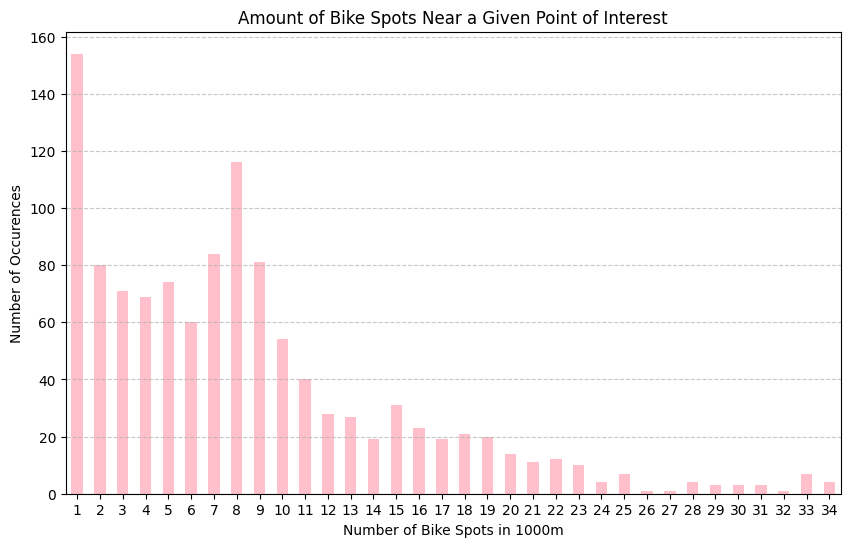

In [7]:
# plotting the frequency of Bike Spots near Points of Interest
plt.figure(figsize=(10, 6))
YCRDataFrequency.plot(kind='bar', color='pink')
plt.title('Amount of Bike Spots Near a Given Point of Interest')
plt.xlabel('Number of Bike Spots in 1000m')
plt.ylabel('Number of Occurences')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

We can see that the distribution of Bike Spots near Points of Interst isn't linear. While over 150 Points of Interest have only 1 Bike Spot within a 1000m radius, over 110 have only 8 Bike Spots within the same radius, while around 80 Points of Interest have only 2 Bike Spots near.